C:\Users\Владелец\AppData\Local\Temp\ipykernel_16880\474563356.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


Overall churn probability: 0.2654
P(Churn | Month-to-month): 0.4271
P(Churn | tenure < 12): 0.4828
P(Churn | Fiber optic): 0.4189
P(Churn | Electronic check): 0.4529
P(Churn | Month-to-month and Fiber optic): 0.5461
Lift: 2.06
Churn by contract:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64
Lowest churn contract: Two year with rate 0.0283
Senior churn: 0.4168, Non-senior: 0.2361
Senior higher: True
Paperless churn: 0.3357, Non-paperless: 0.1633
Difference: 0.1724
Top 5 features by max deviation: ['Contract', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection']


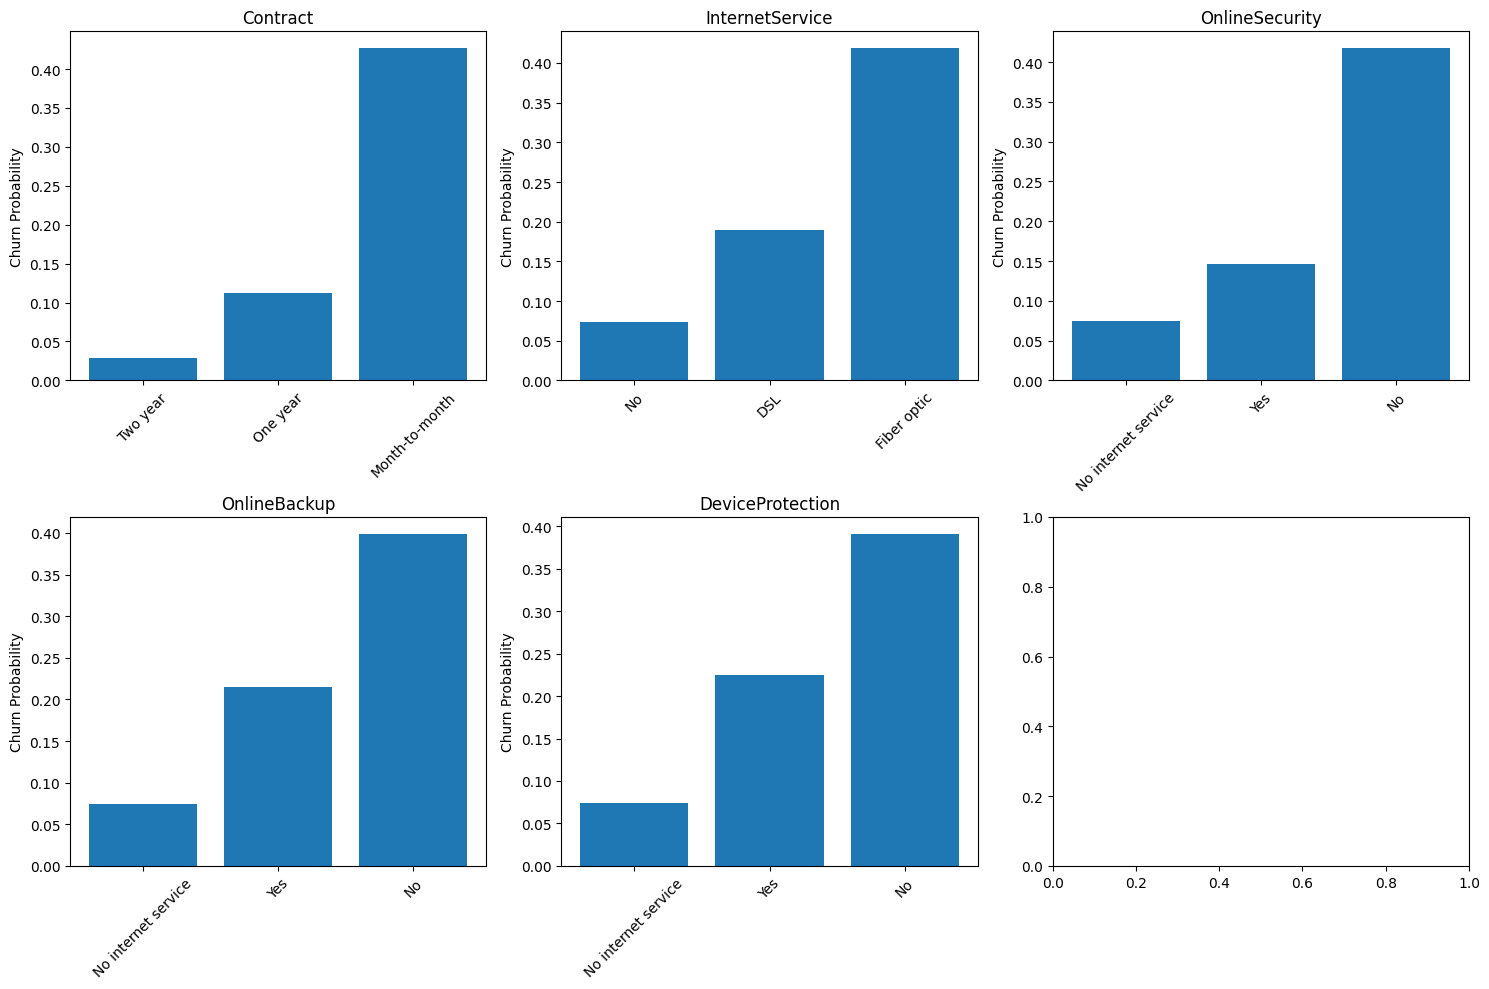

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill missing TotalCharges with 0 (since tenure=0)
df['TotalCharges'].fillna(0, inplace=True)

# Overall churn
overall = (df['Churn'] == 'Yes').mean()
print(f"Overall churn probability: {overall:.4f}")

# Conditional
cond_month = df[df['Contract'] == 'Month-to-month']['Churn'].eq('Yes').mean()
cond_tenure_lt12 = df[df['tenure'] < 12]['Churn'].eq('Yes').mean()
cond_fiber = df[df['InternetService'] == 'Fiber optic']['Churn'].eq('Yes').mean()
cond_ec = df[df['PaymentMethod'] == 'Electronic check']['Churn'].eq('Yes').mean()
print(f"P(Churn | Month-to-month): {cond_month:.4f}")
print(f"P(Churn | tenure < 12): {cond_tenure_lt12:.4f}")
print(f"P(Churn | Fiber optic): {cond_fiber:.4f}")
print(f"P(Churn | Electronic check): {cond_ec:.4f}")

# Joint
joint = df[(df['Contract'] == 'Month-to-month') & (df['InternetService'] == 'Fiber optic')]['Churn'].eq('Yes').mean()
print(f"P(Churn | Month-to-month and Fiber optic): {joint:.4f}")
lift = joint / overall
print(f"Lift: {lift:.2f}")

# Contract type churn
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean())
print("Churn by contract:")
print(contract_churn)
lowest_contract = contract_churn.idxmin()
print(f"Lowest churn contract: {lowest_contract} with rate {contract_churn.min():.4f}")

# Senior
senior = df[df['SeniorCitizen']==1]['Churn'].eq('Yes').mean()
non_senior = df[df['SeniorCitizen']==0]['Churn'].eq('Yes').mean()
print(f"Senior churn: {senior:.4f}, Non-senior: {non_senior:.4f}")
print(f"Senior higher: {senior > non_senior}")

# Paperless
paper = df[df['PaperlessBilling']=='Yes']['Churn'].eq('Yes').mean()
non_paper = df[df['PaperlessBilling']=='No']['Churn'].eq('Yes').mean()
print(f"Paperless churn: {paper:.4f}, Non-paperless: {non_paper:.4f}")
print(f"Difference: {paper - non_paper:.4f}")

# Top 5 features: we need to compute for each categorical feature the range of churn rates.
# Let's list categorical features: gender, SeniorCitizen, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod.
# We'll compute for each feature the maximum absolute deviation from overall churn among its categories.
features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
deviations = {}
for col in features:
    rates = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean())
    max_dev = (rates - overall).abs().max()
    deviations[col] = max_dev
top5 = sorted(deviations, key=deviations.get, reverse=True)[:5]
print("Top 5 features by max deviation:", top5)
# Then plot bar chart of churn rates for each category of these features.
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()
for i, feat in enumerate(top5):
    rates = df.groupby(feat)['Churn'].apply(lambda x: (x=='Yes').mean()).sort_values()
    axes[i].bar(rates.index, rates.values)
    axes[i].set_title(feat)
    axes[i].set_ylabel('Churn Probability')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

=== НАША МОДЕЛЬ (CUSTOM NAIVE BAYES) ===
Accuracy: 0.7203690560681334
Precision: 0.4837133550488599
Recall: 0.7941176470588235
F1-score: 0.6012145748987854
Confusion Matrix:
 [[718 317]
 [ 77 297]]
AUC: 0.8120

=== МОДЕЛЬ SKLEARN (CategoricalNB) ===
Accuracy: 0.7203690560681334
Precision: 0.4837133550488599
Recall: 0.7941176470588235
F1-score: 0.6012145748987854
Confusion Matrix:
 [[718 317]
 [ 77 297]]
AUC: 0.8120


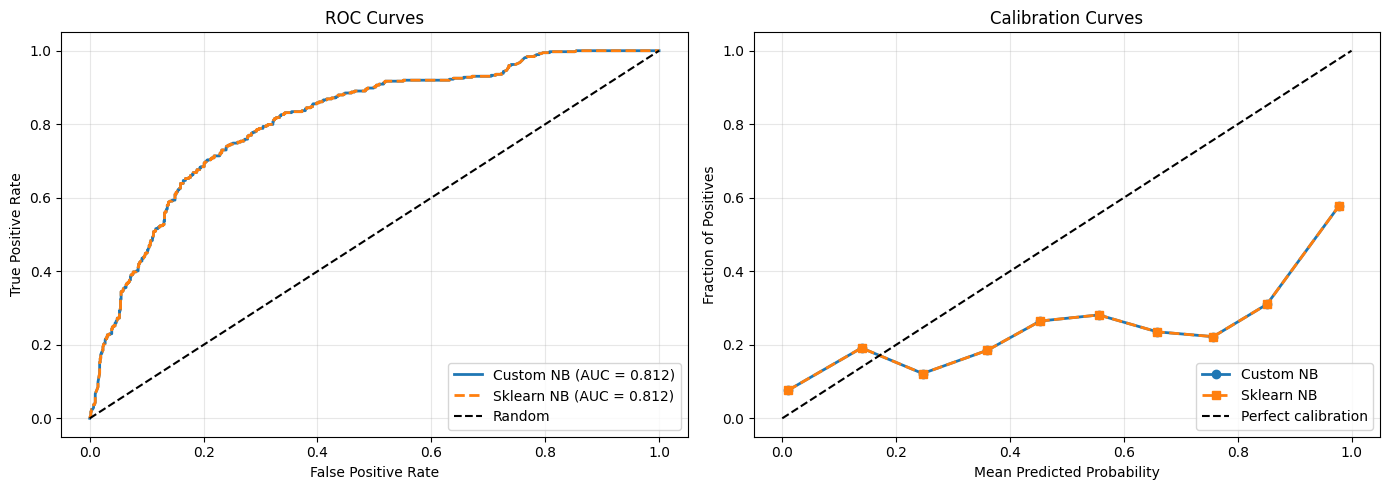


=== СРАВНЕНИЕ МЕТРИК ===
Metric          Custom NB       Sklearn NB     
Accuracy        0.7204          0.7204         
Precision       0.4837          0.4837         
Recall          0.7941          0.7941         
F1-score        0.6012          0.6012         
AUC             0.8120          0.8120         


In [16]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             roc_auc_score)
from sklearn.naive_bayes import CategoricalNB

# ================== 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ==================
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Дискретизация числовых признаков (5 бинов)
df['tenure_bin'] = pd.cut(df['tenure'], bins=5, labels=False)
df['MonthlyCharges_bin'] = pd.cut(df['MonthlyCharges'], bins=5, labels=False)
df['TotalCharges_bin'] = pd.cut(df['TotalCharges'], bins=5, labels=False)

# Набор признаков (все категориальные, включая бины)
feature_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod',
                'tenure_bin', 'MonthlyCharges_bin', 'TotalCharges_bin']

X = df[feature_cols].copy()
y = (df['Churn'] == 'Yes').astype(int)

# Единое кодирование категорий (чтобы train/test имели одинаковые коды)
for col in X.columns:
    X[col] = X[col].astype('category').cat.codes

# Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ================== 2. НАИВНЫЙ БАЙЕСОВСКИЙ КЛАССИФИКАТОР (С НУЛЯ) ==================
class NaiveBayesCategorical:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes = None
        self.priors = {}
        self.probs = {}

    def fit(self, X, y):
        self.classes = y.unique()
        n_samples = len(y)
        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = len(X_c) / n_samples
            self.probs[c] = {}
            for col in X.columns:
                possible = X[col].unique()
                n_possible = len(possible)
                counts = X_c[col].value_counts()
                prob_dict = {}
                for v in possible:
                    cnt = counts.get(v, 0)
                    prob_dict[v] = (cnt + self.alpha) / (len(X_c) + self.alpha * n_possible)
                self.probs[c][col] = prob_dict

    def predict_proba(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_probs = np.zeros((n_samples, n_classes))

        for i, (idx, row) in enumerate(X.iterrows()):
            for j, c in enumerate(self.classes):
                log_prior = math.log(self.priors[c])
                log_likelihood = 0.0
                for col in X.columns:
                    val = row[col]
                    # Если значение не встречалось в обучении, используем сглаживание
                    prob = self.probs[c][col].get(val, self.alpha / (len(self.probs[c][col]) * self.priors[c]))
                    log_likelihood += math.log(prob)
                log_probs[i, j] = log_prior + log_likelihood

        # Softmax для получения вероятностей
        max_log = np.max(log_probs, axis=1, keepdims=True)
        exp_log = np.exp(log_probs - max_log)
        probs = exp_log / np.sum(exp_log, axis=1, keepdims=True)
        return probs

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

# Обучение нашей модели
nb_custom = NaiveBayesCategorical(alpha=1)
nb_custom.fit(X_train, y_train)

# Предсказания
y_pred_custom = nb_custom.predict(X_test)
y_proba_custom = nb_custom.predict_proba(X_test)[:, 1]

# Оценка
print("=== НАША МОДЕЛЬ (CUSTOM NAIVE BAYES) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1-score:", f1_score(y_test, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

# ROC и AUC
fpr_custom, tpr_custom, _ = roc_curve(y_test, y_proba_custom)
roc_auc_custom = auc(fpr_custom, tpr_custom)
print(f"AUC: {roc_auc_custom:.4f}")

# ================== 3. РУЧНАЯ КАЛИБРОВОЧНАЯ КРИВАЯ ==================
def calibration_curve_manual(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    prob_true = []
    prob_pred = []
    for i in range(n_bins):
        bin_mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.sum(bin_mask) > 0:
            prob_true.append(np.mean(y_true[bin_mask]))
            prob_pred.append(np.mean(y_prob[bin_mask]))
        else:
            # Пустой бин – пропускаем или добавляем среднюю точку (по желанию)
            # Здесь мы просто не добавляем пустые бины
            continue
    return np.array(prob_true), np.array(prob_pred)

prob_true_custom, prob_pred_custom = calibration_curve_manual(y_test, y_proba_custom, n_bins=10)

# ================== 4. МОДЕЛЬ SKLEARN ==================
print("\n=== МОДЕЛЬ SKLEARN (CategoricalNB) ===")
sk_nb = CategoricalNB(alpha=1)
sk_nb.fit(X_train, y_train)
y_pred_sk = sk_nb.predict(X_test)
y_proba_sk = sk_nb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_sk))
print("Precision:", precision_score(y_test, y_pred_sk))
print("Recall:", recall_score(y_test, y_pred_sk))
print("F1-score:", f1_score(y_test, y_pred_sk))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sk))

fpr_sk, tpr_sk, _ = roc_curve(y_test, y_proba_sk)
roc_auc_sk = auc(fpr_sk, tpr_sk)
print(f"AUC: {roc_auc_sk:.4f}")

prob_true_sk, prob_pred_sk = calibration_curve_manual(y_test, y_proba_sk, n_bins=10)

# ================== 5. ПОСТРОЕНИЕ ГРАФИКОВ ==================
plt.figure(figsize=(14, 5))

# ROC-кривая
plt.subplot(1, 2, 1)
plt.plot(fpr_custom, tpr_custom, label=f'Custom NB (AUC = {roc_auc_custom:.3f})', linewidth=2)
plt.plot(fpr_sk, tpr_sk, label=f'Sklearn NB (AUC = {roc_auc_sk:.3f})', linestyle='--', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Калибровочный график
plt.subplot(1, 2, 2)
plt.plot(prob_pred_custom, prob_true_custom, marker='o', label='Custom NB', linewidth=2)
plt.plot(prob_pred_sk, prob_true_sk, marker='s', label='Sklearn NB', linestyle='--', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ================== 6. СРАВНЕНИЕ МЕТРИК ==================
print("\n=== СРАВНЕНИЕ МЕТРИК ===")
print(f"{'Metric':<15} {'Custom NB':<15} {'Sklearn NB':<15}")
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_pred_custom):<15.4f} {accuracy_score(y_test, y_pred_sk):<15.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred_custom):<15.4f} {precision_score(y_test, y_pred_sk):<15.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred_custom):<15.4f} {recall_score(y_test, y_pred_sk):<15.4f}")
print(f"{'F1-score':<15} {f1_score(y_test, y_pred_custom):<15.4f} {f1_score(y_test, y_pred_sk):<15.4f}")
print(f"{'AUC':<15} {roc_auc_custom:<15.4f} {roc_auc_sk:<15.4f}")

Точность значений оценок риска, связанная с соответствием между предполагаемым и наблюдаемым числом событий, называется «калибровкой».


In [12]:
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split

# ================== 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ==================
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # исправлено, без inplace

# Дискретизация числовых признаков (5 бинов)
df['tenure_bin'] = pd.cut(df['tenure'], bins=5, labels=False)
df['MonthlyCharges_bin'] = pd.cut(df['MonthlyCharges'], bins=5, labels=False)
df['TotalCharges_bin'] = pd.cut(df['TotalCharges'], bins=5, labels=False)

# Набор признаков (все категориальные, включая бины)
feature_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod',
                'tenure_bin', 'MonthlyCharges_bin', 'TotalCharges_bin']

X = df[feature_cols].copy()
y = (df['Churn'] == 'Yes').astype(int)

# Единое кодирование категорий (чтобы train/test имели одинаковые коды)
for col in X.columns:
    X[col] = X[col].astype('category').cat.codes

# Разделение на train/test (80/20) – для обучения модели
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ================== 2. НАИВНЫЙ БАЙЕСОВСКИЙ КЛАССИФИКАТОР (исправленный) ==================
class NaiveBayesCategorical:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes = None
        self.priors = {}
        self.probs = {}

    def fit(self, X, y):
        self.classes = y.unique()
        n_samples = len(y)
        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = len(X_c) / n_samples
            self.probs[c] = {}
            for col in X.columns:
                possible = X[col].unique()
                n_possible = len(possible)
                counts = X_c[col].value_counts()
                prob_dict = {}
                for v in possible:
                    cnt = counts.get(v, 0)
                    prob_dict[v] = (cnt + self.alpha) / (len(X_c) + self.alpha * n_possible)
                self.probs[c][col] = prob_dict

    def predict_proba(self, X):
        """
        X : pd.DataFrame
        Возвращает массив вероятностей размера (n_samples, n_classes)
        """
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_probs = np.zeros((n_samples, n_classes))
        
        # Перебираем строки
        for i, (idx, row) in enumerate(X.iterrows()):
            for j, c in enumerate(self.classes):
                log_prior = math.log(self.priors[c])
                log_likelihood = 0.0
                for col in X.columns:
                    val = row[col]
                    # Если значение не встречалось в обучении, используем сглаживание
                    prob = self.probs[c][col].get(val, self.alpha / (len(self.probs[c][col]) * self.priors[c]))
                    log_likelihood += math.log(prob)
                log_probs[i, j] = log_prior + log_likelihood
        
        # Softmax для получения вероятностей
        max_log = np.max(log_probs, axis=1, keepdims=True)
        exp_log = np.exp(log_probs - max_log)
        probs = exp_log / np.sum(exp_log, axis=1, keepdims=True)
        return probs

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

# Обучение модели
nb = NaiveBayesCategorical(alpha=1)
nb.fit(X_train, y_train)

# Предсказание вероятностей для всего датасета (для бизнес‑анализа)
proba_all = nb.predict_proba(X)[:, 1]
df['churn_prob'] = proba_all

# ================== 3. БИЗНЕС‑АНАЛИЗ (TASK 3) ==================
CLV = 2000          # средняя пожизненная ценность клиента
cost = 300          # стоимость кампании удержания
success_rate = 0.4  # вероятность успеха

# ------------------------------------------------------------
# 3.1. Ожидаемая ценность таргетирования отдельного клиента
# ------------------------------------------------------------
p = 0.8
max_spend = p * CLV * success_rate
print(f"Максимальная сумма, которую можно потратить на клиента с p=0.8: ${max_spend:.2f}")

# Ожидаемая прибыль от таргетирования всех клиентов с вероятностью > 0.5
high_risk_05 = df[df['churn_prob'] > 0.5]
profit_05 = (high_risk_05['churn_prob'] * CLV * success_rate - cost).sum()
print(f"\nКлиентов с p>0.5: {len(high_risk_05)}")
print(f"Ожидаемая прибыль от таргетирования всех таких клиентов: ${profit_05:,.2f}")

# ------------------------------------------------------------
# 3.2. Матрица сегментации по риску и ценности
# ------------------------------------------------------------
high_value = df['MonthlyCharges'] > 70
high_risk = df['churn_prob'] > 0.6

segments = {
    'HV/HR': df[high_value & high_risk],
    'HV/LR': df[high_value & ~high_risk],
    'LV/HR': df[~high_value & high_risk],
    'LV/LR': df[~high_value & ~high_risk]
}

print("\n--- Матрица сегментации ---")
for name, seg in segments.items():
    n = len(seg)
    expected_loss = (seg['churn_prob'] * CLV).sum()
    net_gain = (seg['churn_prob'] * CLV * success_rate - cost).sum()
    print(f"{name}: клиентов={n}, ожидаемый убыток=${expected_loss:,.0f}, чистая прибыль от кампании=${net_gain:,.0f}")

# ------------------------------------------------------------
# 3.3. Оптимизация бюджета $50,000
# ------------------------------------------------------------
budget = 50000
df['ev'] = df['churn_prob'] * CLV * success_rate - cost
df_sorted = df.sort_values('ev', ascending=False)

cum_cost = 0
targeted = []
for idx, row in df_sorted.iterrows():
    if cum_cost + cost <= budget:
        targeted.append(idx)
        cum_cost += cost
    else:
        break

targeted_df = df.loc[targeted]
print(f"\n--- Оптимизация бюджета ${budget} ---")
print(f"Клиентов в таргете: {len(targeted_df)}")
print(f"Ожидаемая общая прибыль: ${targeted_df['ev'].sum():.2f}")
high_risk_total = (df['churn_prob'] > 0.6).sum()
high_risk_covered = (targeted_df['churn_prob'] > 0.6).sum()
print(f"Процент покрытия сегмента высокого риска: {high_risk_covered/high_risk_total*100:.1f}%")

# ------------------------------------------------------------
# 3.4. Анализ чувствительности (три сценария)
# ------------------------------------------------------------
scenarios = [
    {'name': 'Низкий успех (20%)', 'success_rate': 0.2, 'cost': 300, 'CLV': 2000},
    {'name': 'Высокая стоимость ($500)', 'success_rate': 0.4, 'cost': 500, 'CLV': 2000},
    {'name': 'Низкий CLV ($1500)', 'success_rate': 0.4, 'cost': 300, 'CLV': 1500}
]

print("\n--- Анализ чувствительности ---")
for scen in scenarios:
    df['ev_scen'] = df['churn_prob'] * scen['CLV'] * scen['success_rate'] - scen['cost']
    df_sorted_scen = df.sort_values('ev_scen', ascending=False)
    cum_cost_scen = 0
    targeted_scen = []
    for idx, row in df_sorted_scen.iterrows():
        if cum_cost_scen + scen['cost'] <= budget:
            targeted_scen.append(idx)
            cum_cost_scen += scen['cost']
        else:
            break
    targeted_df_scen = df.loc[targeted_scen]
    print(f"\n{scen['name']}:")
    print(f"  Клиентов в таргете: {len(targeted_df_scen)}")
    print(f"  Ожидаемая прибыль: ${targeted_df_scen['ev_scen'].sum():.2f}")

Максимальная сумма, которую можно потратить на клиента с p=0.8: $640.00

Клиентов с p>0.5: 3081
Ожидаемая прибыль от таргетирования всех таких клиентов: $1,295,120.98

--- Матрица сегментации ---
HV/HR: клиентов=1931, ожидаемый убыток=$3,613,328, чистая прибыль от кампании=$866,031
HV/LR: клиентов=1652, ожидаемый убыток=$359,476, чистая прибыль от кампании=$-351,810
LV/HR: клиентов=987, ожидаемый убыток=$1,755,165, чистая прибыль от кампании=$405,966
LV/LR: клиентов=2473, ожидаемый убыток=$265,016, чистая прибыль от кампании=$-635,894

--- Оптимизация бюджета $50000 ---
Клиентов в таргете: 166
Ожидаемая общая прибыль: $82878.91
Процент покрытия сегмента высокого риска: 5.7%

--- Анализ чувствительности ---

Низкий успех (20%):
  Клиентов в таргете: 166
  Ожидаемая прибыль: $16539.45

Высокая стоимость ($500):
  Клиентов в таргете: 100
  Ожидаемая прибыль: $29942.51

Низкий CLV ($1500):
  Клиентов в таргете: 166
  Ожидаемая прибыль: $49709.18
